In [1]:
import math
import sys

import torch
import torch.nn as nn
import yaml

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
import seaborn as sns

from eeg.gesture2hand import TemporalDataset, TemporalModel
from eeg.gesture2hand.datasets.utils import Colors

In [2]:
with open("../config/temporal.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)

    stride = config["stride"]
    val_ratio = config["val_ratio"]
    num_features = config["num_features"]
    d_model = 128
    num_heads = 4
    num_layers = 4
    dropout = config["dropout"]
    vocab_size = config["vocab_size"]

    device = config["device"]
    batch_size = config["batch_size"]
    sequence_length = config["seq_length"]
    save_ckpt_path = config["save_ckpt_path"]

gesture_labels = ["Fist", "Left", "Fingers", "Open"]

In [ ]:
print(f"{Colors.HEADER}Loading validation dataset...{Colors.ENDC}")
val_dataset = TemporalDataset(
    mode="val",
    seq_len=sequence_length,
    stride=stride,
    device=device,
    verbose=True,
    region_tokenizer_path="../models/appendages"
)

val_sample_weights, _ = val_dataset.get_sampler_weights()
val_sampler = torch.utils.data.WeightedRandomSampler(
    weights=val_sample_weights,
    num_samples=len(val_sample_weights),
    replacement=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    drop_last=False,
    sampler=val_sample_weights
)

print(f"{Colors.OKGREEN}Dataset loaded. Validation batches: {len(val_loader)}{Colors.ENDC}\n")


Loading validation dataset...
Initializing dataset...
Getting VQVAE model...
Getting EEG data...
Computing bandpower features at 128.0 Hz...
Number of frequencies: (65,)
Bandpower features shape: (243912, 84) or (T, 84)
Filtered & processed EEG data.
Getting labels...
Getting appendage data...
Retrieved appendage data.
Successful retrieved all data.
Pre-computing VQ-VAE tokens...


100%|██████████| 112/112 [01:09<00:00,  1.62it/s]



EEG shape (30Hz):    (228491, 14)
Bandpower shape:     (228491, 84)
Appendages shape:    (228491, 12)
VQ-VAE tokens shape: (228491,)
Labels shape:        (228491,)


EEG chunks (30Hz):    (228491, 14)
Bandpower chunks:     (228491, 84)
Appendages chunks:    (228491, 12)
VQ-VAE tokens chunks: (228491,)
Labels chunks:        (228491,)

Number of blocks: (3807,) 

Splitting data into train and val sets...

Total number of chunks: 3040

Training/validation split index: 3040

Fist chunks (27.2% open)
Left chunks (13.6% open)
Fingers chunks (11.5% open)
Open chunks (47.7% open)

Dataset loaded. Validation batches: 95



In [4]:
print(f"{Colors.HEADER}Loading model...{Colors.ENDC}")
model = TemporalModel(
    num_features=84,
    d_model=64,
    num_heads=4,
    num_layers=2,
    dropout=0.3,
    vocab_size=4,
).to(device)

param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of model parameters: {param_count:,}")

Loading model...
Number of model parameters: 74,789


In [5]:
def load_checkpoint(epoch: int | None = None) -> bool:
    """Load model checkpoint. Returns True if successful."""
    if epoch is not None:
        ckpt_path = f"{save_ckpt_path}_epoch_{epoch}.pth"
    else:
        ckpt_path = f"{save_ckpt_path}.pth"
    
    try:
        state_dict = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(state_dict["model"])
        print(f"{Colors.OKGREEN}Loaded checkpoint: {ckpt_path}{Colors.ENDC}\n")
        return True
    except FileNotFoundError:
        print(f"{Colors.FAIL}Checkpoint not found: {ckpt_path}{Colors.ENDC}")
        print(f"{Colors.WARNING}Using random initialization for inference{Colors.ENDC}\n")
        return False

# try to load checkpoint (modify epoch parameter to load specific checkpoint)
load_checkpoint(epoch=50)

Checkpoint not found: /var/log/thavamount/eeg_ckpts/temporal/temporal_epoch_50.pth
Using random initialization for inference



False

In [6]:
model.eval()

all_predictions = []
all_labels = []
all_probs = []

print(f"{Colors.OKBLUE}Running inference on validation set...{Colors.ENDC}")
with torch.no_grad():
    for batch_idx, (eeg, bp, apps, tokens, labels, durations, masks) in enumerate(tqdm(val_loader)):
        # move to device
        bp = bp.to(device)  # (B, T, 84)
        labels = labels.to(device)  # (B,)
        
        # forward pass
        logits = model(bp)  # (B, vocab_size)
        
        # get predictions and probabilities
        probs = torch.softmax(logits, dim=1)  # (B, vocab_size)
        preds = torch.argmax(logits, dim=1)  # (B,)
        
        # store results
        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print(f"{Colors.OKGREEN}Inference complete!{Colors.ENDC}")
print(f"Total samples: {len(all_predictions)}\n")

Running inference on validation set...


100%|██████████| 95/95 [00:02<00:00, 32.35it/s]

Inference complete!
Total samples: 3040



In [7]:
overall_accuracy = accuracy_score(all_labels, all_predictions)
print(f"{Colors.HEADER}=== VALIDATION METRICS ==={Colors.ENDC}")
print(f"Overall Accuracy: {overall_accuracy:.4f}\n")

# per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_predictions, average=None
)

print(f"{Colors.OKBLUE}Per-Class Metrics:{Colors.ENDC}")
print(f"{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
print("-" * 58)
for i, label in enumerate(gesture_labels):
    print(
        f"{label:<12} {precision[i]:<12.4f} {recall[i]:<12.4f} "
        f"{f1[i]:<12.4f} {int(support[i]):<10}"
    )

# macro averages
print(f"\n{Colors.OKCYAN}Macro Averages:{Colors.ENDC}")
print(f"Precision: {precision.mean():.4f}")
print(f"Recall:    {recall.mean():.4f}")
print(f"F1-Score:  {f1.mean():.4f}\n")

# weighted averages
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_labels, all_predictions, average="weighted"
)
print(f"{Colors.OKCYAN}Weighted Averages:{Colors.ENDC}")
print(f"Precision: {prec_weighted:.4f}")
print(f"Recall:    {rec_weighted:.4f}")
print(f"F1-Score:  {f1_weighted:.4f}\n")

# per-class accuracy
print(f"{Colors.OKBLUE}Per-Class Accuracy (Recall):{Colors.ENDC}")
for i, label in enumerate(gesture_labels):
    class_mask = all_labels == i
    if class_mask.sum() > 0:
        class_accuracy = accuracy_score(all_labels[class_mask], all_predictions[class_mask])
        print(f"{label:<12}: {class_accuracy:.4f}")

# --- error analysis ---

errors = all_predictions != all_labels
correct = all_predictions == all_labels

print(f"\n{Colors.HEADER}Error Analysis{Colors.ENDC}")
print(f"Total errors: {errors.sum()} / {len(all_predictions)} ({100 * errors.sum() / len(all_predictions):.2f}%)")
print(f"Correct: {correct.sum()} / {len(all_predictions)} ({100 * correct.sum() / len(all_predictions):.2f}%)\n")

# most common confusions
if errors.sum() > 0:
    error_indices = np.where(errors)[0]
    error_labels = all_labels[error_indices]
    error_predictions = all_predictions[error_indices]
    
    print(f"{Colors.OKBLUE}Most Common Confusions (Top 10):{Colors.ENDC}")
    confusions = {}
    for gt, pred in zip(error_labels, error_predictions):
        key = f"{gesture_labels[gt]} → {gesture_labels[pred]}"
        confusions[key] = confusions.get(key, 0) + 1
    
    sorted_confusions = sorted(confusions.items(), key=lambda x: x[1], reverse=True)
    for confusion, count in sorted_confusions[:10]:
        print(f"  {confusion}: {count} times\n")

/root/eeg/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


=== VALIDATION METRICS ===
Overall Accuracy: 0.1388

Per-Class Metrics:
Class        Precision    Recall       F1-Score     Support   
----------------------------------------------------------
Fist         0.0000       0.0000       0.0000       818       
Left         0.1388       1.0000       0.2438       422       
Fingers      0.0000       0.0000       0.0000       347       
Open         0.0000       0.0000       0.0000       1453      

Macro Averages:
Precision: 0.0347
Recall:    0.2500
F1-Score:  0.0609

Weighted Averages:
Precision: 0.0193
Recall:    0.1388
F1-Score:  0.0338

Per-Class Accuracy (Recall):
Fist        : 0.0000
Left        : 1.0000
Fingers     : 0.0000
Open        : 0.0000

Error Analysis
Total errors: 2618 / 3040 (86.12%)
Correct: 422 / 3040 (13.88%)

Most Common Confusions (Top 10):
  Open → Left: 1453 times

  Fist → Left: 818 times

  Fingers → Left: 347 times



/root/eeg/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [8]:
# print(f"{Colors.HEADER}Generating visualizations...{Colors.ENDC}")

# # plot confusion matrix
# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# cm = confusion_matrix(all_labels, all_predictions)
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=gesture_labels,
#             yticklabels=gesture_labels, ax=axes[0], cbar=True)
# axes[0].set_title("Confusion Matrix", fontsize=14, fontweight="bold")
# axes[0].set_ylabel("Ground Truth")
# axes[0].set_xlabel("Prediction")

# # plot prediction time series
# sample_size = min(500, len(all_predictions))
# x = np.arange(sample_size)
# axes[1].plot(x, all_labels[:sample_size], label="Ground Truth", marker="o", markersize=3, alpha=0.7)
# axes[1].plot(x, all_predictions[:sample_size], label="Predictions", marker="s", markersize=3, alpha=0.7)
# axes[1].set_title(f"Predictions vs Ground Truth (first {sample_size} samples)", fontsize=14, fontweight="bold")
# axes[1].set_xlabel("Sample Index")
# axes[1].set_ylabel("Gesture Class")
# axes[1].set_yticks(range(vocab_size))
# axes[1].set_yticklabels(gesture_labels)
# axes[1].legend()
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig("temporal_predictions.png", dpi=150, bbox_inches='tight')
# print(f"{Colors.OKGREEN}Saved: temporal_predictions.png{Colors.ENDC}")
# plt.close()

# # plot prediction confidence
# fig, ax = plt.subplots(figsize=(12, 6))
# max_probs = np.max(all_probs, axis=1)
# ax.hist(max_probs, bins=30, edgecolor="black", alpha=0.7)
# ax.set_ylabel("Count", fontsize=12) # 
# ax.set_title("Distribution of Prediction Confidence", fontsize=14, fontweight="bold")
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig("temporal_confidence.png", dpi=150, bbox_inches='tight')
# print(f"{Colors.OKGREEN}Saved: temporal_confidence.png{Colors.ENDC}")
# plt.close()

# # error confidence analysis
# if errors.sum() > 0:
#     error_probs = all_probs[errors]
#     correct_max_probs = np.max(all_probs[correct], axis=1)
#     error_max_probs = np.max(error_probs, axis=1)
    
#     fig, ax = plt.subplots(figsize=(10, 6))
#     ax.hist(correct_max_probs, bins=30, alpha=0.6, label="Correct Predictions", edgecolor="black")
#     ax.hist(error_max_probs, bins=30, alpha=0.6, label="Incorrect Predictions", edgecolor="black")
#     ax.set_xlabel("Maximum Probability", fontsize=12)
#     ax.set_ylabel("Count", fontsize=12)
#     ax.set_title("Prediction Confidence: Correct vs Incorrect", fontsize=14, fontweight="bold")
#     ax.legend()
#     ax.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.savefig("temporal_confidence_comparison.png", dpi=150, bbox_inches='tight')
#     print(f"{Colors.OKGREEN}Saved: temporal_confidence_comparison.png{Colors.ENDC}")
#     print(f"\n{Colors.OKBLUE}Confidence Statistics:{Colors.ENDC}")
#     print(f"Correct predictions - Mean confidence: {correct_max_probs.mean():.4f}")
#     print(f"Incorrect predictions - Mean confidence: {error_max_probs.mean():.4f}\n")
#     plt.close()

# print(f"{Colors.OKGREEN}Inference complete!{Colors.ENDC}")

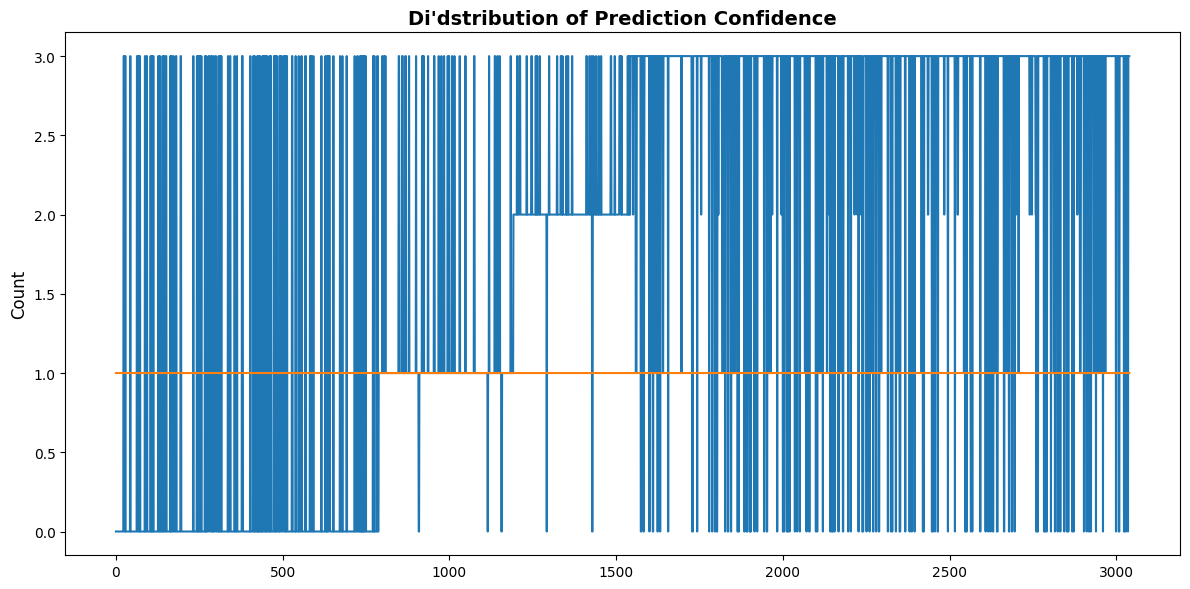

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(all_labels)
ax.plot(all_predictions)
ax.set_ylabel("Count", fontsize=12) # 
ax.set_title("Di'dstribution of Prediction Confidence", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
plt.close()

In [10]:
print(val_dataset.bp_chunks[0].std())
print(val_dataset.bp_chunks[0].mean())
print(val_dataset.bp_chunks[-1].std())
print(val_dataset.bp_chunks[-1].mean())

1.0882541
0.011519713
0.779854
0.048622847


In [4]:
images, bp, apps, tokens, labels, durations, masks = next(iter(val_loader))
print(f"Batch labels: {labels.numpy()}") 
print(f"Class counts in this batch: {np.bincount(labels.numpy(), minlength=4)}")

Batch labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Class counts in this batch: [32  0  0  0]


In [5]:
print(f"EEG Split: {len(val_dataset.eeg_chunks_split)}")
print(f"BP Split: {len(val_dataset.bp_chunks_split)}")
print(f"Sampler Weights: {len(val_sample_weights)}")

EEG Split: 3040
BP Split: 3040
Sampler Weights: 3040
